Each user now has:

Feature	Meaning
total_spend	Long-term spending magnitude
avg_transaction_value	Typical purchase size
transaction_count	Activity level
quantity_mean	Average quantity per purchase
quantity_std	Quantity variability
return_rate	Refund/cancellation behaviour
spending_volatility	Daily behavioural stability
top_stockcode	Product preference (categorical)

These are REAL behavioural signals.

No normalization yet — everything remains raw.

In [ ]:
import pandas as pd
import numpy as np
import sys
import os

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

from shared_core.features import calculate_user_features
# Load cleaned raw transactions
df = pd.read_csv("../data/interim/cleaned_transactions.csv")
print("Loaded cleaned dataset:", df.shape)
# ------------------------------
# 1. Aggregate Spending Metrics
# ------------------------------
user_features = df.groupby("Customer ID").agg(
    total_spend = ("TransactionValue", "sum"),
    avg_transaction_value = ("TransactionValue", "mean"),
    transaction_count = ("TransactionValue", "count"),
    quantity_mean = ("Quantity", "mean"),
    quantity_std = ("Quantity", "std"),
)
# Replace NaN std with 0 for users with 1 transaction
user_features["quantity_std"] = user_features["quantity_std"].fillna(0)
# ------------------------------
# 2. Return Behaviour
# ------------------------------
user_returns = df.groupby("Customer ID")["IsReturn"].mean()
user_features["return_rate"] = user_returns
# ------------------------------
# 3. Spending Volatility
# ------------------------------
daily_spend = (
    df.assign(day=df["InvoiceDate"].astype(str).str[:10])
      .groupby(["Customer ID","day"])["TransactionValue"]
      .sum()
)
vol = daily_spend.groupby("Customer ID").std().fillna(0)
user_features["spending_volatility"] = vol
# ------------------------------
# 4. Category Preferences (High-Level Feature)
# ------------------------------
top_stock = (
    df.groupby(["Customer ID","StockCode"])["Quantity"]
      .sum()
      .groupby("Customer ID")
      .idxmax()
)
user_features["top_stockcode"] = top_stock.map(lambda x: x[1])
# ------------------------------
# Save engineered features
# ------------------------------
user_features.to_csv("../data/interim/context_features_raw.csv")
print("Saved context_features_raw.csv:", user_features.shape)
user_features.head()


Loaded cleaned dataset: (410732, 10)
Saved context_features_raw.csv: (4381, 8)


,total_spend,avg_transaction_value,transaction_count,quantity_mean,quantity_std,return_rate,spending_volatility,top_stockcode
Customer ID,,,,,,,,
12346,-51.74,-1.149778,45,1.177778,2.488966,0.266667,125.941673,TEST001
12347,1323.32,18.638310,71,11.661972,7.456433,0.000000,70.894526,22492
12348,222.16,11.108000,20,18.650000,7.125012,0.000000,0.000000,21213
12349,2646.99,24.738224,107,9.233645,8.408867,0.046729,682.647313,16156S
12351,300.93,14.330000,21,12.428571,8.732534,0.000000,0.000000,22045


NORMALIZATION (ONLY ON ENGINEERED FEATURES)

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import joblib

# Load engineered features
df = pd.read_csv("../data/interim/context_features_raw.csv")

print("Loaded feature dataset:", df.shape)

# ------------------------------
# 1. Select numeric columns
# ------------------------------
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
numeric_cols = [col for col in numeric_cols if col != "Customer ID"]

print("Scaling these columns:", numeric_cols)

# ------------------------------
# 2. Apply Min–Max Scaling
# ------------------------------
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# ------------------------------
# 3. Save scaled features + scaler
# ------------------------------
df_scaled.to_csv("../data/processed/context_features_scaled.csv", index=False)
joblib.dump(scaler, "../zone_2_artifacts/cmab_scaler.pkl")

print("Saved context_features_scaled.csv:", df_scaled.shape)

print("Scaler saved to cmab_scaler.pkl")
df_scaled.head()


Loaded feature dataset: (4381, 9)
Scaling these columns: ['total_spend', 'avg_transaction_value', 'transaction_count', 'quantity_mean', 'quantity_std', 'return_rate', 'spending_volatility']
Saved context_features_scaled.csv: (4381, 9)
Scaler saved to cmab_scaler.pkl


,Customer ID,total_spend,avg_transaction_value,transaction_count,quantity_mean,quantity_std,return_rate,spending_volatility,top_stockcode
0,12346,0.068302,0.899537,0.007711,0.004287,0.000631,0.266667,0.007470,TEST001
1,12347,0.072050,0.900246,0.012268,0.006904,0.001890,0.000000,0.004205,22492
2,12348,0.069049,0.899976,0.003330,0.008648,0.001806,0.000000,0.000000,21213
3,12349,0.075658,0.900465,0.018577,0.006298,0.002131,0.046729,0.040491,16156S
4,12351,0.069264,0.900092,0.003505,0.007095,0.002213,0.000000,0.000000,22045


Cross check everything

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans

In [6]:
# Cell 3: Missingness & duplicates
print("=== MISSING VALUES (column-wise) ===")
print((df.isnull().sum()).sort_values(ascending=False))

print("\n=== DUPLICATE ROWS ===")
print("Duplicate rows count:", df.duplicated().sum())

# Optional: missingness heatmap (if any missing)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(10,2))
    sns.heatmap(df.isnull(), cbar=False)
    plt.title("Missingness heatmap")
    plt.show()


=== MISSING VALUES (column-wise) ===
Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID         0
Country             0
TransactionValue    0
IsReturn            0
dtype: int64

=== DUPLICATE ROWS ===
Duplicate rows count: 0


In [7]:
# Cell 4: Summary statistics
num_cols = ['Quantity','Price','TransactionValue']
print("=== NUMERIC SUMMARY (before any transforms) ===")
display(df[num_cols].describe().T)

print("\n=== CATEGORICALS (top values) ===")
for c in ['Country','StockCode']:
    print(f"\nTop values for {c}:")
    display(df[c].value_counts().head(10))


=== NUMERIC SUMMARY (before any transforms) ===


,count,mean,std,min,25%,50%,75%,max
Quantity,410732.0,12.922592,102.038529,-9360.000,2.00,5.00,12.00,19152.00
Price,410732.0,3.908653,71.717492,0.001,1.25,1.95,3.75,25111.09
TransactionValue,410732.0,20.243993,100.714472,-25111.090,4.50,11.80,19.50,15818.40



=== CATEGORICALS (top values) ===

Top values for Country:


Country
United Kingdom     372683
EIRE                 8705
Germany              8113
France               5692
Netherlands          2767
Spain                1271
Switzerland          1187
Belgium              1052
Portugal             1023
Channel Islands       906
Name: count, dtype: int64


Top values for StockCode:


StockCode
85123A    3199
22423     1861
85099B    1772
21212     1566
21232     1500
20725     1370
84879     1362
21754     1202
84991     1175
20914     1125
Name: count, dtype: int64

Feature_engeered

In [ ]:
df = pd.read_csv("../data/interim/context_features_raw.csv")

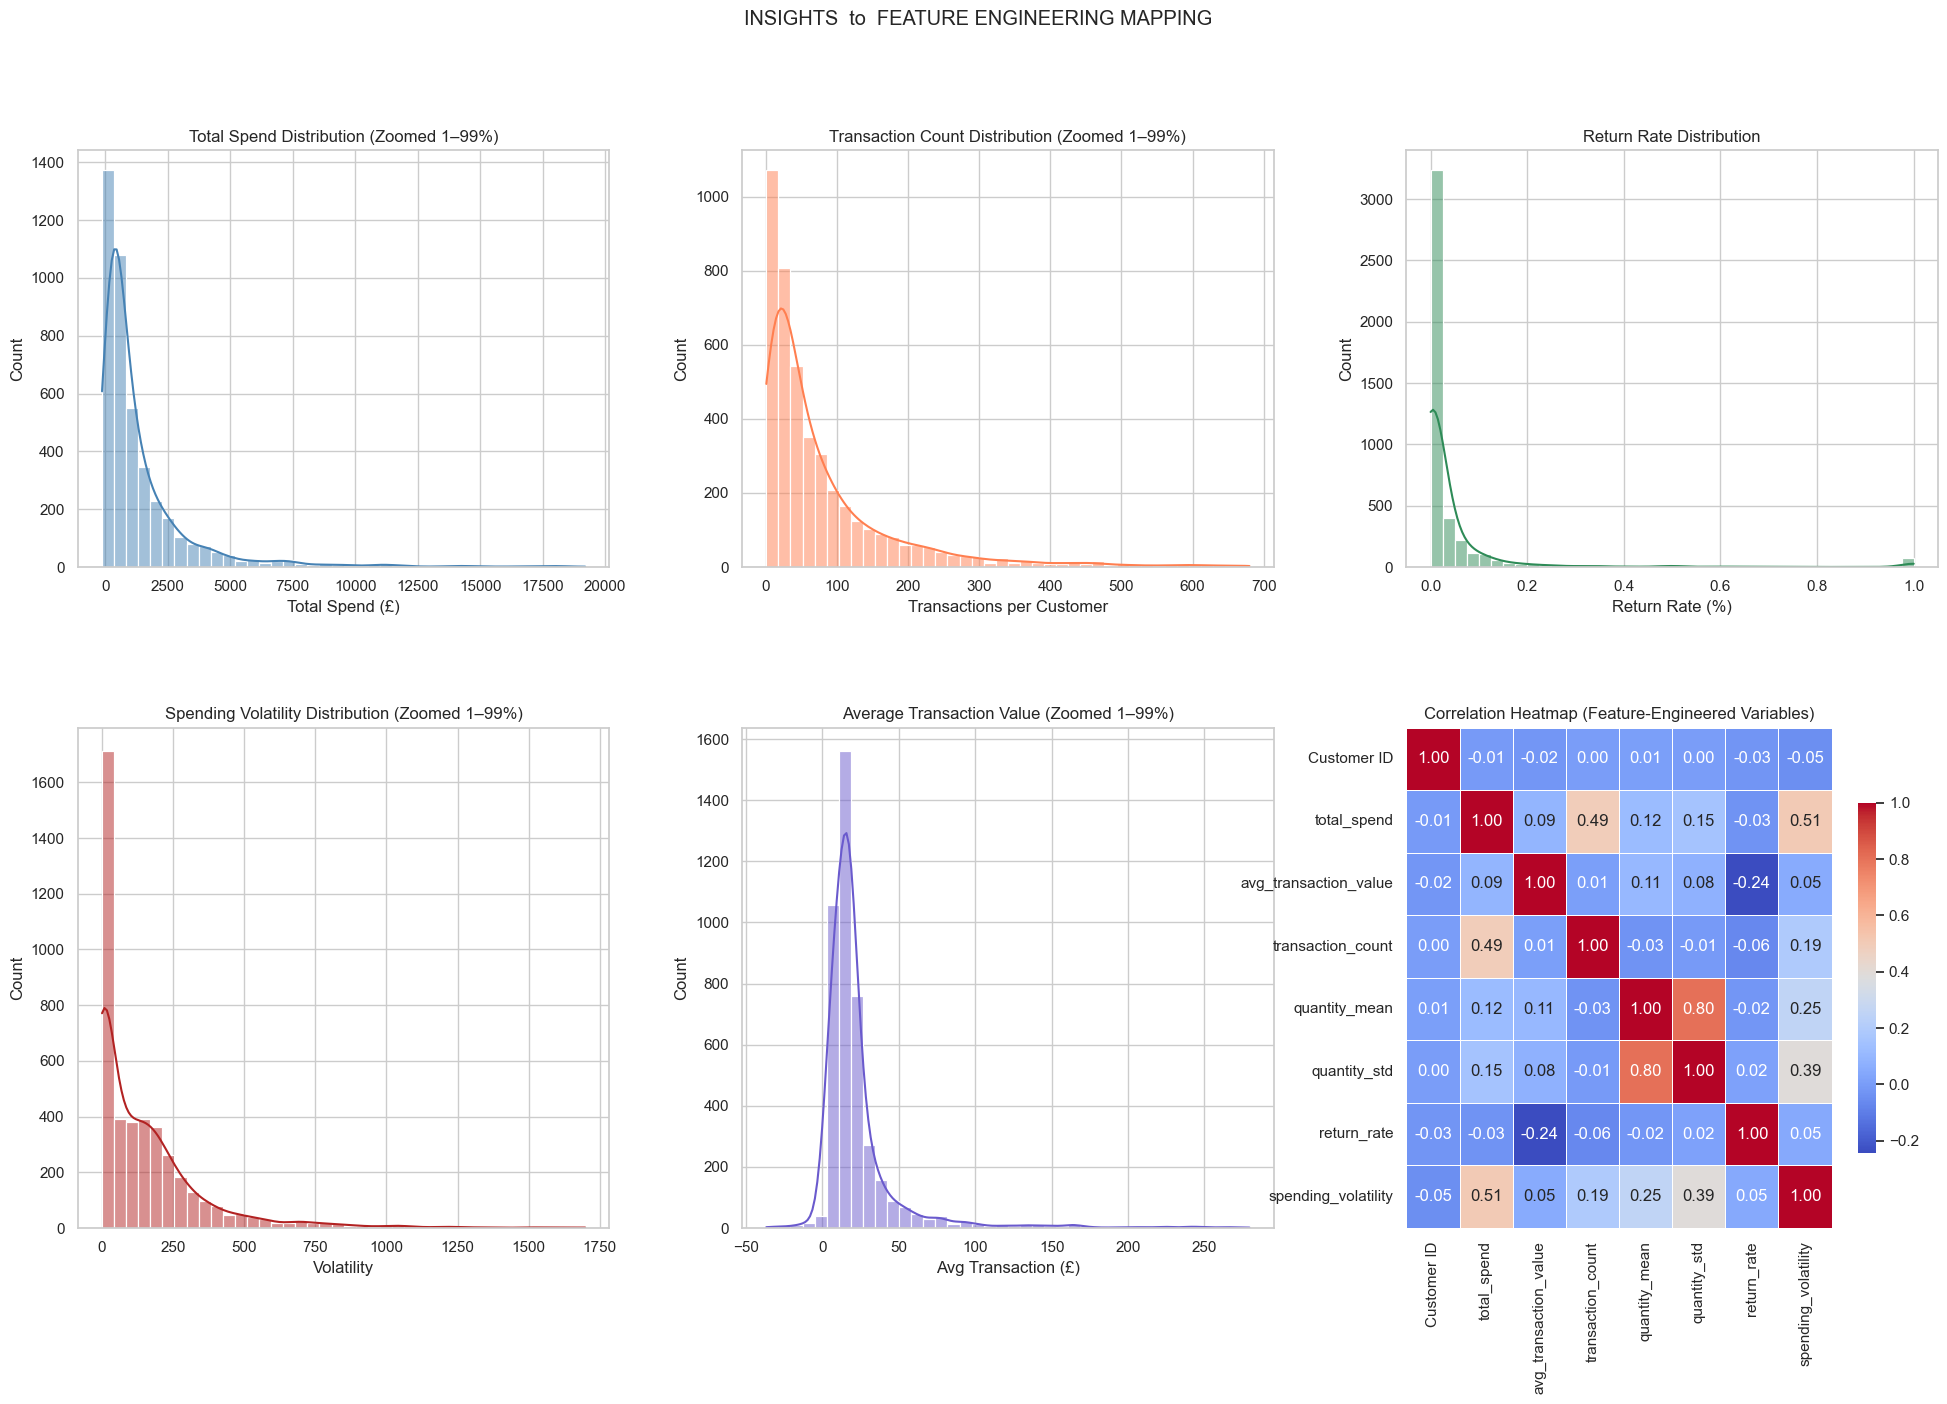

In [19]:
fig = plt.figure(figsize=(24, 14))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.2], hspace=0.35, wspace=0.25)
fig.suptitle("INSIGHTS  to  FEATURE ENGINEERING MAPPING")
# Axes
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# -------- 1. Total Spend Distribution --------
sns.histplot(zoom(customer_df["total_spend"]), bins=40, kde=True, ax=ax1, color="steelblue")
ax1.set_title("Total Spend Distribution (Zoomed 1–99%)")
ax1.set_xlabel("Total Spend (£)")

# -------- 2. Transaction Count --------
sns.histplot(zoom(customer_df["transaction_count"]), bins=40, kde=True, ax=ax2, color="coral")
ax2.set_title("Transaction Count Distribution (Zoomed 1–99%)")
ax2.set_xlabel("Transactions per Customer")

# -------- 3. Return Rate --------
sns.histplot(customer_df["return_rate"], bins=40, kde=True, ax=ax3, color="seagreen")
ax3.set_title("Return Rate Distribution")
ax3.set_xlabel("Return Rate (%)")

# -------- 4. Spending Volatility --------
sns.histplot(zoom(customer_df["spending_volatility"]), bins=40, kde=True, ax=ax4, color="firebrick")
ax4.set_title("Spending Volatility Distribution (Zoomed 1–99%)")
ax4.set_xlabel("Volatility")

# -------- 5. Average Transaction Value --------
sns.histplot(zoom(customer_df["avg_transaction_value"]), bins=40, kde=True, ax=ax5, color="slateblue")
ax5.set_title("Average Transaction Value (Zoomed 1–99%)")
ax5.set_xlabel("Avg Transaction (£)")

# -------- 6. Better Heatmap (Full Size) --------
corr = customer_df.drop(columns=["top_stockcode"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    ax=ax6,
    cbar_kws={'shrink': 0.7}
)
ax6.set_title("Correlation Heatmap (Feature-Engineered Variables)")

plt.show()
